<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/21z_scoreIQRimpericalRule.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

According to the Empirical Rule (68-95-99.7), if BMI is approximately
normally distributed with mean=30 and std=6, what percentage of people have
BMI above 42?  

Given mean 30

Standard deviation sigma 6

Target BMI 42

calculation (42-30)/6 = 2

A BMI of 42 is exactly 2 standard deviations above the mean ( mean + 2sigma)

The rule states that 95% of the data falls within 2 standard deviations mean +- 2sigma of the mean (between a BMI of 18 and 42)

Since 95% is in the middle, the remaining data in both outer tails combined is:\(100\%-95\%=5\%\)

Because a normal distribution curve is perfectly symmetrical, divide this remaining percentage equally between both the lower and upper tails:\(5\%\div 2=2.5\%\)Therefore, exactly 2.5% of people have a BMI above 42.

You detect that the 'charges' column has a Z-score outlier threshold at |Z| >
3. A student removes ALL rows with |Z| > 3 before the train-test split. Identify
two problems with this approach.

The two primary problems with this approach are data leakage and the distortion of the real-world data distribution.

1. Data Leakage (Information Leakage)The Cause:
Calculating Z-scores requires the mean and standard deviation of the entire dataset.The Issue: This includes data points from the future test set.The Impact: Information from the unseen test data leaks into the training process.The Result: Test set performance metrics will be overly optimistic and unrealistic.

2. Disregarding Real and Important DataThe Cause: High "charges" are often valid, real-world occurrences (e.g., rare, expensive medical events).The Issue: The model never learns to predict these high-value cases.The Impact: The model will consistently under-predict high costs in production.The Result: A vital part of the target distribution is completely ignored.How to Fix ItStep 1: Split the data into train and test sets first.Step 2: Calculate mean and standard deviation using only the training set.Step 3: Filter outliers from the training set using those training metrics.Step 4: Keep test set outliers to evaluate how the model handles real-world extremes.

Why might the IQR method detect different outliers than the Z-score
method on the same column? In which situation is each method preferred?

The IQR and Z-score methods detect different outliers because they rely on different statistical assumptions: Z-score assumes a normal distribution and uses metrics highly sensitive to outliers, while IQR is non-parametric and robust against skewed data.

When to Prefer Each MethodPrefer the IQR Method when:The data is heavily skewed: For example, medical "charges", income, or real estate prices.The data contains severe outliers: You need a baseline that won't be distorted by extreme data points.The distribution is unknown: It works reliably regardless of the data's underlying shape.

Prefer the Z-score Method when:The data is normally distributed: For example, physical measurements like height, weight, or standardized test scores.You want a parametric standard: It works well when you explicitly want to flag data points based on their exact probability of occurrence under a normal curve (e.g., flagging points beyond \(3sigma\)).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv('/content/insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


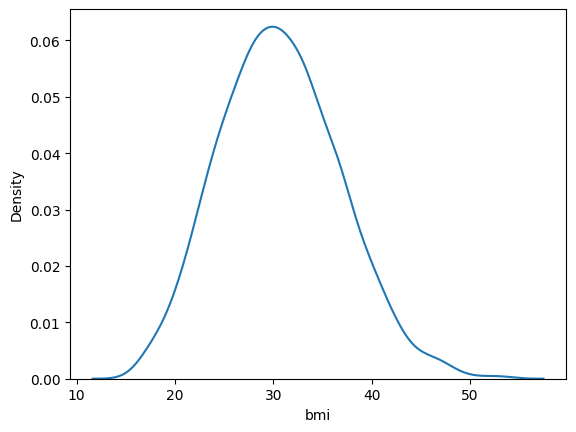

In [3]:
sns.kdeplot(data = df, x = 'bmi')
plt.show()

In [4]:
print(df['bmi'].skew())

0.2840471105987448


In [5]:
mean_of_charges = df['charges'].mean()
mean_of_charges = df['charges'].std()

df['zscore_charges'] = (df['charges']-mean_of_charges)/mean_of_charges

outliers_charges = df[abs(df['zscore_charges']) >3]

print(len(outliers_charges))

display(outliers_charges)

15


,age,sex,bmi,children,smoker,region,charges,zscore_charges
34,28,male,36.400,1,yes,southwest,51194.55914,3.227458
175,63,female,37.700,0,yes,southwest,48824.45000,3.031743
281,54,male,40.565,3,yes,northeast,48549.17835,3.009012
330,61,female,36.385,1,yes,northeast,48517.56315,3.006401
488,44,female,38.060,0,yes,southeast,48885.13561,3.036754
530,57,male,42.130,1,yes,southeast,48675.51770,3.019444
543,54,female,47.410,0,yes,southeast,63770.42801,4.265926
577,31,female,38.095,1,yes,northeast,58571.07448,3.836583
819,33,female,35.530,0,yes,northwest,55135.40209,3.552878
901,60,male,40.920,0,yes,southeast,48673.55880,3.019283


In [6]:
charges_Q1 = df['charges'].quantile(0.25)
charges_Q3 = df['charges'].quantile(0.75)

charges_IQR = charges_Q3 - charges_Q1

charges_minimum = charges_Q1 - 1.5 * charges_IQR
charges_maximum = charges_Q3 + 1.5 * charges_IQR

print(charges_minimum , charges_maximum)

charges_outlier_IQR = df[(df['charges']<charges_minimum) | (df['charges']>charges_maximum)]

print(len(charges_outlier_IQR))
display(charges_outlier_IQR)

-13109.1508975 34489.350562499996
139


,age,sex,bmi,children,smoker,region,charges,zscore_charges
14,27,male,42.130,0,yes,southeast,39611.75770,2.270993
19,30,male,35.300,0,yes,southwest,36837.46700,2.041902
23,34,female,31.920,1,yes,northeast,37701.87680,2.113282
29,31,male,36.300,2,yes,southwest,38711.00000,2.196611
30,22,male,35.600,0,yes,southwest,35585.57600,1.938525
...,...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309,4.168688
1301,62,male,30.875,3,yes,northwest,46718.16325,2.857813
1303,43,male,27.800,0,yes,southwest,37829.72420,2.123839
1313,19,female,34.700,2,yes,southwest,36397.57600,2.005577


In statistics, a more conservative outlier detection method is the one that flags fewer outliers. It requires a data point to be more extreme before labeling it as an anomaly.

Z-score method more conservative

In [9]:
df['bmi_category'] = df['bmi']
df.loc[df['bmi']<18.5, 'bmi_category'] = 'Underweight'
df.loc[(df['bmi']>=18.5) & (df['bmi'] <= 24.9), 'bmi_category'] = 'Normal'
df.loc[(df['bmi']>=25) & (df['bmi'] <= 29.9), 'bmi_category'] = 'Overweight'
df.loc[df['bmi']>=30, 'bmi_category'] = 'Underweight'

df

/tmp/ipykernel_2483/4049123782.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Underweight' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df['bmi']<18.5, 'bmi_category'] = 'Underweight'


,age,sex,bmi,children,smoker,region,charges,zscore_charges,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,0.394295,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,-0.857510,Underweight
2,28,male,33.000,3,no,southeast,4449.46200,-0.632580,Underweight
3,33,male,22.705,0,no,northwest,21984.47061,0.815396,Normal
4,32,male,28.880,0,no,northwest,3866.85520,-0.680689,Overweight
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,-0.124646,Underweight
1334,18,female,31.920,0,no,northeast,2205.98080,-0.817838,Underweight
1335,18,female,36.850,0,no,southeast,1629.83350,-0.865414,Underweight
1336,21,female,25.800,0,no,southwest,2007.94500,-0.834191,Overweight


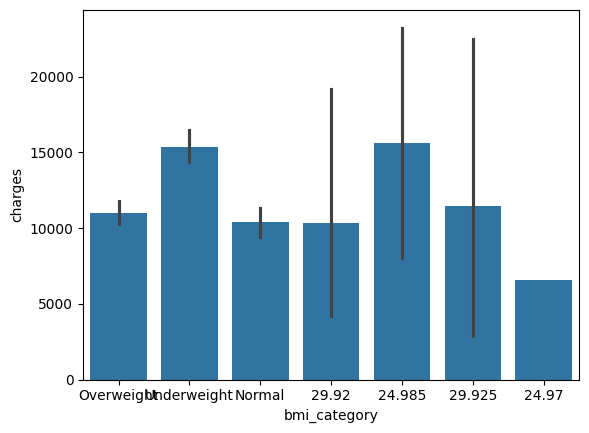

In [10]:
sns.barplot(data = df, x = 'bmi_category', y = 'charges')
plt.show()

Why the Graph Looks This WayIncorrect Categories:

Your bmi_category column contains mixed data types (strings and floats), causing seaborn to treat each unique numeric value as its own separate category.

Confusing Patterns: Because the data is un-grouped, it falsely appears that "Underweight" has much higher charges than "Normal" or "Overweight", which is a result of fragmented data.

Massive Error Bars: The extremely tall black lines (error bars) on the right side show that those groups have very few data points, making the average calculation unreliable.